<a href="https://colab.research.google.com/github/7235SYXD/Real-Estate/blob/main/DSP_on_Real_Estate_(NB_5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — INSTALL LIBRARIES                                      ║
# ╚══════════════════════════════════════════════════════════════════╝

import subprocess, sys
for lib in ["kagglehub","catboost","shap","optuna",
            "vaderSentiment","yake","textstat"]:
    subprocess.run([sys.executable,"-m","pip","install",lib,"-q"])
print("All libraries installed.")

All libraries installed.


In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — GOOGLE DRIVE                                           ║
# ╚══════════════════════════════════════════════════════════════════╝

import os, shutil
from google.colab import drive, files

drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/RealEstate_TXNY"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory: {SAVE_DIR}")

Mounted at /content/drive
Save directory: /content/drive/MyDrive/RealEstate_TXNY


In [3]:
# ╔════════════════════════════════════════════════════╗
# ║  CELL 3 — IMPORT ALL LIBRARIES                     ║
# ╚════════════════════════════════════════════════════╝

import os
import re
import warnings
from pathlib import Path
import gc # Import the garbage collection module

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import math
from tensorflow.keras import layers as KL

# Sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, f1_score, classification_report,
    accuracy_score,
)
from sklearn.linear_model import Ridge as RidgeMeta
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import learning_curve

# Gradient boosting
!pip install catboost
from catboost import CatBoostRegressor, CatBoostClassifier
import xgboost as xgb

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Hyperparameter tuning
!pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Interpretability
import shap

# NLP
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
!pip install yake
import yake
!pip install textstat
import textstat

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 60)
print("All libraries imported successfully.")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  tensorflow : {tf.__version__}")
print(f"  sklearn    : OK")
print("=" * 60)

All libraries imported successfully.
  pandas     : 2.2.2
  numpy      : 2.0.2
  tensorflow : 2.20.0
  sklearn    : OK


# Notebook 5 Setup - Restore state from Notebook 4

Restores all the variables produced in Notebooks 1–4 (feature matrices, fitted
base models, encoders, scalers, etc.) from the dill checkpoint, plus the
Keras MLP model from its own `.keras` file, so that we can continue with this notebook, straight from Cell 26A without re-running any earlier notebook.



In [4]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  NOTEBOOK 5: SETUP — restores state from Notebook 4              ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Loads the variables from dill checkpoint saved by Notebook 4.

Restore mechanism:
    1. pip install dill (fast, already cached)
    2. Open checkpoint_4_to_5.pkl → dill.load() → globals().update()
       Makes the Notebook 4 variables available in this session.
    3. Open checkpoint_4_to_5_keras.json → for each entry,
       keras.models.load_model(path) → globals()[name] = model
       Restores mlp_base_model (the baseline 2-layer MLP from Cell 19A).
"""

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "dill", "-q"])
import dill, json

CKPT_DIR  = f"{SAVE_DIR}/checkpoints"
CKPT_NAME = "checkpoint_4_to_5"

with open(f"{CKPT_DIR}/{CKPT_NAME}.pkl", "rb") as f:
    _state = dill.load(f)
globals().update(_state)

with open(f"{CKPT_DIR}/{CKPT_NAME}_keras.json") as f:
    _keras_paths = json.load(f)
for _name, _path in _keras_paths.items():
    globals()[_name] = keras.models.load_model(_path)

print("=" * 65)
print(f"CHECKPOINT RESTORED <- {CKPT_DIR}/{CKPT_NAME}.pkl")
print("=" * 65)
print(f"  Variables restored    : {len(_state)}")
print(f"  Keras models restored : {list(_keras_paths.keys()) or 'none'}")
if "df_combined" in globals():
    print(f"  df_combined shape      : {df_combined.shape}")
print(f"\nNotebook 4 state loaded successfully.")
print("Continuing from Cell 26A below, unchanged.")

CHECKPOINT RESTORED <- /content/drive/MyDrive/RealEstate_TXNY/checkpoints/checkpoint_4_to_5.pkl
  Variables restored    : 420
  Keras models restored : ['mlp_base_model', 'mlp_tuned', 'mlp_f']
  df_combined shape      : (119979, 51)

Notebook 4 state loaded successfully.
Continuing from Cell 26A below, unchanged.


# Cell 26A - Training vs Validation Curves

Identifying under/overfitting for the classification stage.

- **Figure 1:** Decision Tree train/val accuracy vs `max_depth` (1→20),
  with optimal depth annotated and shade the under/overfit zones.
- **Figure 2:** Two panels — (A) train/val log-loss vs `max_depth`,
  (B) 5-fold learning curve (accuracy vs training-set size, ±1 std bands).





CELL 26A — TRAINING/VALIDATION CURVES

Sweeping Decision Tree max_depth 1 → 20 ...
  Optimal depth (max val acc)  : 20  →  val acc  = 0.6781
  Optimal depth (min val loss) : 6  →  val loss = 0.5993
Computing learning curve (5-fold CV, 10 size steps) ...


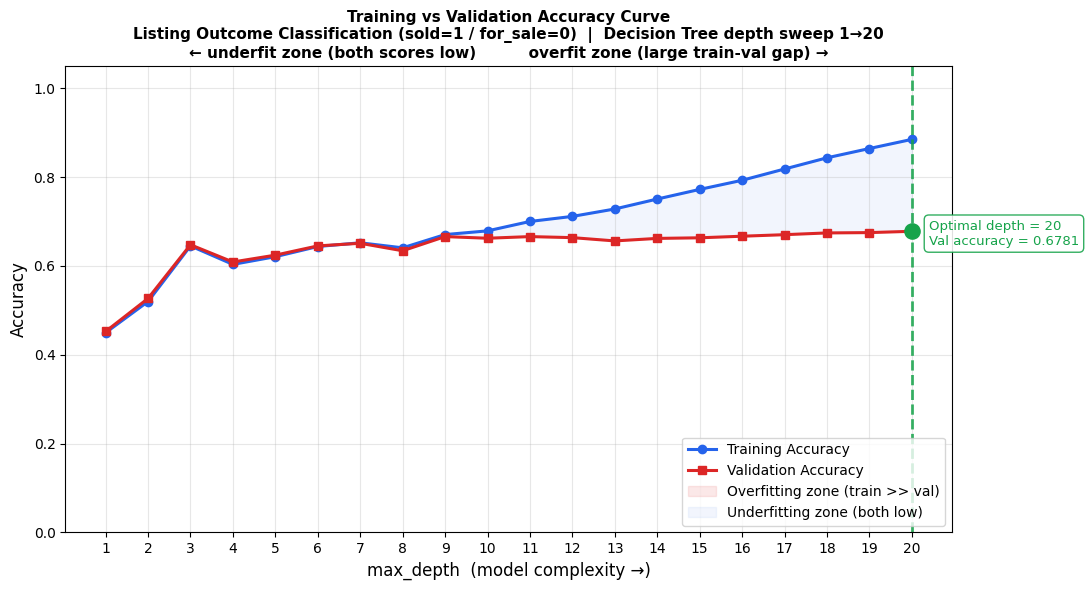


FIGURE 1 saved → /content/drive/MyDrive/RealEstate_TXNY/cell26A_accuracy_curve.png


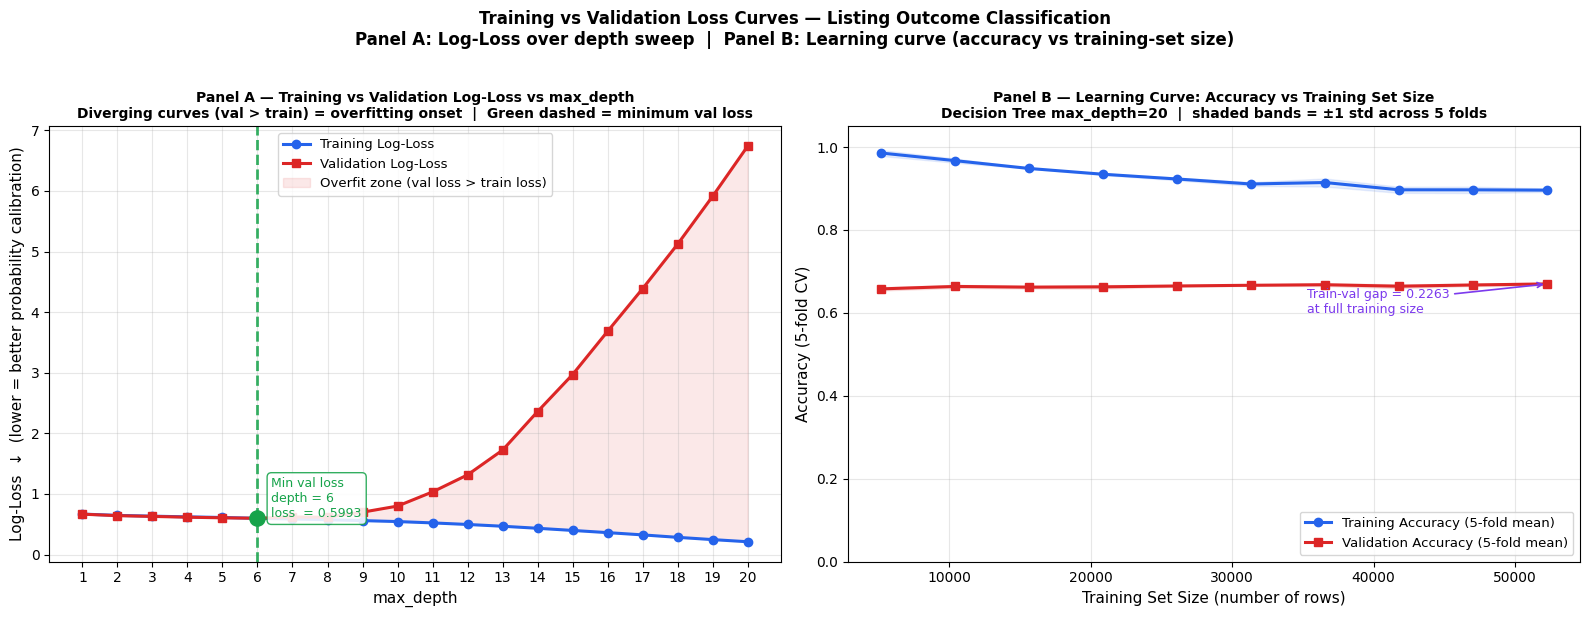

FIGURE 2 saved → /content/drive/MyDrive/RealEstate_TXNY/cell26A_loss_curve.png

CELL 26A — COMPLETE

Figure 1  Training vs Validation Accuracy Curve
  Optimal depth = 20  |  Val accuracy = 0.6781

Figure 2  Training vs Validation Loss Curve
  Min val log-loss = 0.5993  at depth = 6
  Train-val gap at full data = 0.2263

Both figures saved to /content/drive/MyDrive/RealEstate_TXNY/


In [5]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 26A — TRAINING / VALIDATION CURVES                         ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Visualize 2 accuracy and loss curves

  FIGURE 1 — Training vs Validation ACCURACY Curve
      Decision Tree max_depth 1→20.
      Shows the underfitting zone where both the accuracies are low, the sweet spot
      is a spot where the optimal depth helps to peak the val accuracy,
      and the overfitting zone shows large train-val gap.
      Marked with the optimal depth.

  FIGURE 2 — Training vs Validation LOSS Curve  (2 panels)
      Panel A: Log-Loss vs max_depth — diverging curves reveal overfit.
      Panel B: Learning curve — accuracy vs training-set size (5-fold CV)
               with ±1 std-dev bands. Shows whether more data would help.

Inputs (all from CELL 19B):
    Xctr, Xcva   : classification feature matrices
    yc_tr, yc_va : classification targets
    SEED, SAVE_DIR: global constants from earlier cells

Outputs:
    cell26A_accuracy_curve.png
    cell26A_loss_curve.png
"""

print("=" * 65)
print("CELL 26A — TRAINING/VALIDATION CURVES")
print("=" * 65)

# ── Palette ───────────────────────────────────────────────────────
_C_TR        = "#2563EB"   # blue  — training
_C_VA        = "#DC2626"   # red   — validation
_C_BEST      = "#16A34A"   # green — optimal point / best model

# ── Step 1: Depth sweep (accuracy + log-loss over max_depth 1→20) ─
DEPTHS     = list(range(1, 21))
tr_acc_lst = []
va_acc_lst = []
tr_los_lst = []
va_los_lst = []

print("\nSweeping Decision Tree max_depth 1 → 20 ...")
for d in DEPTHS:
    _dt = DecisionTreeClassifier(
        max_depth=d, random_state=SEED, class_weight="balanced")
    _dt.fit(Xctr, yc_tr)
    tr_acc_lst.append(accuracy_score(yc_tr, _dt.predict(Xctr)))
    va_acc_lst.append(accuracy_score(yc_va, _dt.predict(Xcva)))
    tr_los_lst.append(log_loss(yc_tr, _dt.predict_proba(Xctr)))
    va_los_lst.append(log_loss(yc_va, _dt.predict_proba(Xcva)))

BEST_D    = DEPTHS[int(np.argmax(va_acc_lst))]   # depth with max val accuracy
BEST_ACC  = max(va_acc_lst)
BEST_LI   = int(np.argmin(va_los_lst))           # depth with min val loss
BEST_LOSS = min(va_los_lst)
print(f"  Optimal depth (max val acc)  : {BEST_D}  →  val acc  = {BEST_ACC:.4f}")
print(f"  Optimal depth (min val loss) : {DEPTHS[BEST_LI]}  →  val loss = {BEST_LOSS:.4f}")

# ── Step 2: Learning curve (accuracy vs training-set size) ────────
print("Computing learning curve (5-fold CV, 10 size steps) ...")
_lc_sizes, _lc_tr, _lc_va = learning_curve(
    DecisionTreeClassifier(
        max_depth=BEST_D, random_state=SEED, class_weight="balanced"),
    Xctr, yc_tr,
    cv=5, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1)

# ════════════════════════════════════════════════════════════════
# FIGURE 1 — Training vs Validation ACCURACY Curve
# ════════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(DEPTHS, tr_acc_lst, "o-", color=_C_TR, lw=2.2, ms=6,
         label="Training Accuracy")
ax1.plot(DEPTHS, va_acc_lst, "s-", color=_C_VA, lw=2.2, ms=6,
         label="Validation Accuracy")

# Shade zones
ax1.fill_between(
    DEPTHS, tr_acc_lst, va_acc_lst,
    where=[d > BEST_D for d in DEPTHS],
    alpha=0.10, color=_C_VA, label="Overfitting zone (train >> val)")
ax1.fill_between(
    DEPTHS, tr_acc_lst, va_acc_lst,
    where=[d <= BEST_D for d in DEPTHS],
    alpha=0.06, color=_C_TR, label="Underfitting zone (both low)")

# Optimal depth annotation
ax1.axvline(BEST_D, color=_C_BEST, lw=2, ls="--", alpha=0.85)
ax1.scatter([BEST_D], [BEST_ACC], color=_C_BEST, s=120, zorder=5)
ax1.text(
    BEST_D + 0.4, BEST_ACC - 0.03,
    f"Optimal depth = {BEST_D}\nVal accuracy = {BEST_ACC:.4f}",
    color=_C_BEST, fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
              edgecolor=_C_BEST, alpha=0.88))

ax1.set_xlabel("max_depth  (model complexity →)", fontsize=12)
ax1.set_ylabel("Accuracy", fontsize=12)
ax1.set_title(
    "Training vs Validation Accuracy Curve\n"
    "Listing Outcome Classification (sold=1 / for_sale=0)  |  "
    "Decision Tree depth sweep 1→20\n"
    "← underfit zone (both scores low)          "
    "overfit zone (large train-val gap) →",
    fontsize=11, fontweight="bold")
ax1.set_xticks(DEPTHS)
ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=10, loc="lower right")
ax1.grid(alpha=0.3)

plt.tight_layout()
_p1 = f"{SAVE_DIR}/cell26A_accuracy_curve.png"
plt.savefig(_p1, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nFIGURE 1 saved → {_p1}")

# ════════════════════════════════════════════════════════════════
# FIGURE 2 — Training vs Validation LOSS Curve (2 panels)
# ════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel A: Log-Loss vs depth ────────────────────────────────
ax2a = axes2[0]
ax2a.plot(DEPTHS, tr_los_lst, "o-", color=_C_TR, lw=2.2, ms=6,
          label="Training Log-Loss")
ax2a.plot(DEPTHS, va_los_lst, "s-", color=_C_VA, lw=2.2, ms=6,
          label="Validation Log-Loss")
ax2a.fill_between(
    DEPTHS, tr_los_lst, va_los_lst,
    where=[tr < va for tr, va in zip(tr_los_lst, va_los_lst)],
    alpha=0.10, color=_C_VA, label="Overfit zone (val loss > train loss)")

# Mark minimum validation loss
ax2a.axvline(DEPTHS[BEST_LI], color=_C_BEST, lw=2, ls="--", alpha=0.85)
ax2a.scatter([DEPTHS[BEST_LI]], [BEST_LOSS], color=_C_BEST, s=120, zorder=5)
ax2a.text(
    DEPTHS[BEST_LI] + 0.4, BEST_LOSS + 0.02,
    f"Min val loss\ndepth = {DEPTHS[BEST_LI]}\nloss  = {BEST_LOSS:.4f}",
    color=_C_BEST, fontsize=9,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
              edgecolor=_C_BEST, alpha=0.88))

ax2a.set_xlabel("max_depth", fontsize=11)
ax2a.set_ylabel("Log-Loss  ↓  (lower = better probability calibration)", fontsize=11)
ax2a.set_title(
    "Panel A — Training vs Validation Log-Loss vs max_depth\n"
    "Diverging curves (val > train) = overfitting onset  |  "
    "Green dashed = minimum val loss",
    fontsize=10, fontweight="bold")
ax2a.set_xticks(DEPTHS)
ax2a.legend(fontsize=9.5)
ax2a.grid(alpha=0.3)

# ── Panel B: Learning curve (accuracy vs training size) ──────
ax2b = axes2[1]
_tr_m = _lc_tr.mean(axis=1);  _tr_s = _lc_tr.std(axis=1)
_va_m = _lc_va.mean(axis=1);  _va_s = _lc_va.std(axis=1)

ax2b.plot(_lc_sizes, _tr_m, "o-", color=_C_TR, lw=2.2, ms=6,
          label="Training Accuracy (5-fold mean)")
ax2b.plot(_lc_sizes, _va_m, "s-", color=_C_VA, lw=2.2, ms=6,
          label="Validation Accuracy (5-fold mean)")
ax2b.fill_between(_lc_sizes, _tr_m - _tr_s, _tr_m + _tr_s,
                   alpha=0.10, color=_C_TR)
ax2b.fill_between(_lc_sizes, _va_m - _va_s, _va_m + _va_s,
                   alpha=0.12, color=_C_VA)

_final_gap = float(_tr_m[-1] - _va_m[-1])
ax2b.annotate(
    f"Train-val gap = {_final_gap:.4f}\nat full training size",
    xy=(_lc_sizes[-1], float(_va_m[-1])),
    xytext=(_lc_sizes[-2] * 0.75, float(_va_m[-1]) - 0.07),
    fontsize=9, color="#7C3AED",
    arrowprops=dict(arrowstyle="->", color="#7C3AED", lw=1.2))

ax2b.set_xlabel("Training Set Size (number of rows)", fontsize=11)
ax2b.set_ylabel("Accuracy (5-fold CV)", fontsize=11)
ax2b.set_title(
    f"Panel B — Learning Curve: Accuracy vs Training Set Size\n"
    f"Decision Tree max_depth={BEST_D}  |  shaded bands = ±1 std across 5 folds",
    fontsize=10, fontweight="bold")
ax2b.set_ylim(0, 1.05)
ax2b.legend(fontsize=9.5, loc="lower right")
ax2b.grid(alpha=0.3)

fig2.suptitle(
    "Training vs Validation Loss Curves — Listing Outcome Classification\n"
    "Panel A: Log-Loss over depth sweep  |  "
    "Panel B: Learning curve (accuracy vs training-set size)",
    fontsize=12, fontweight="bold", y=1.02)

plt.tight_layout()
_p2 = f"{SAVE_DIR}/cell26A_loss_curve.png"
plt.savefig(_p2, dpi=150, bbox_inches="tight")
plt.show()
print(f"FIGURE 2 saved → {_p2}")

# ── Summary ──────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("CELL 26A — COMPLETE")
print("=" * 65)
print(f"\nFigure 1  Training vs Validation Accuracy Curve")
print(f"  Optimal depth = {BEST_D}  |  Val accuracy = {BEST_ACC:.4f}")
print(f"\nFigure 2  Training vs Validation Loss Curve")
print(f"  Min val log-loss = {BEST_LOSS:.4f}  at depth = {DEPTHS[BEST_LI]}")
print(f"  Train-val gap at full data = {_final_gap:.4f}")
print(f"\nBoth figures saved to {SAVE_DIR}/")

# Cell 27 - Ridge Stacking Meta-Learner

This combines out-of-Fold (OOF)
predictions for the tuned base regressors (Random Forest, CatBoost, HistGradientBoosting and MLP) combine these models into a single stacked prediction using a Ridge regression meta-learner.



*   Builds the OOF meta-feature matrix and fits `ridge_meta`.
*   Displays each base model's coefficient if its near zero then its a *weak contributor* and if its negative then its *hurting the ensemble*.
*   Generates the test-set predictions for each and every tuned base model including the stack.



In [6]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 27 — RIDGE STACKING META-LEARNER                           ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Train a Ridge meta-learner on an OOF predictions.

Why Ridge for the meta-learner:
  • Ridge = L2 is a regularised linear regression. It combines the base model
    predictions with the coefficients which sums upto approximately 1.
  • A coefficient which is close to 0 tells us that model adds little to the ensemble.
  • A negative coefficient tells us the model is hurting the ensemble —
    which flags an unstable model (like MLP if it collapsed).
  • Ridge prevents the meta-learner from overfitting to the noise in
    each base model's OOF predictions.

Meta-feature matrix:
  Columns: [oof_rf, oof_cat, (oof_mlp), oof_hgb, oof_en]
  Rows:    one per training sample (n_train rows)
  Target:  y_reg_train (actual log_price)

Test predictions: each base model predicts on the full test set,
  which produces test-level meta-features for the Ridge meta-learner.
"""

print("=" * 65)
print("CELL 27 — RIDGE STACKING META-LEARNER")
print("=" * 65)


# Define the RidgeMeta class to wrap sklearn.linear_model.Ridge
class RidgeMeta(Ridge):
    def __init__(self, alpha=1.0, **kwargs):
        super().__init__(alpha=alpha, **kwargs)


# Build OOF meta-feature matrix
oof_cols = [oof_rf, oof_cat, oof_hgb]
oof_names = ["RF", "CatBoost", "HGB"]
if INCLUDE_MLP_IN_STACK:
    oof_cols.insert(2, oof_mlp)
    oof_names.insert(2, "MLP")

meta_train = np.column_stack(oof_cols)
print(f"Meta-feature matrix (train): {meta_train.shape}  "
      f"columns={oof_names}")

# Train Ridge meta-learner
ridge_meta = RidgeMeta(alpha=1.0)
ridge_meta.fit(meta_train, yr_train_vals)
print(f"\nRidge meta-learner coefficients:")
for name, coef in zip(oof_names, ridge_meta.coef_):
    bar = "█" * max(0, int(abs(coef) * 20))
    flag = " negative stack" if coef < 0 else ""
    print(f"  {name:14s}: {coef:+.4f}  {bar}{flag}")
print(f"  Intercept     : {ridge_meta.intercept_:.4f}")

# ── Test set predictions ───────────────────────────────────────────
print("\nGenerating test-set predictions from tuned models ...")
p_rf_test  = rf_tuned.predict(Xts_rf)
p_cat_test = cb_tuned.predict(Xts_rf)
p_hgb_test = hgb_tuned.predict(Xts_raw)
p_mlp_test = denorm_y(mlp_tuned.predict(Xts_sc, verbose=0).flatten())

test_cols = [p_rf_test, p_cat_test, p_hgb_test]
test_names = ["RF", "CatBoost", "HGB"]
if INCLUDE_MLP_IN_STACK:
    test_cols.insert(2, p_mlp_test)
    test_names.insert(2, "MLP")

meta_test   = np.column_stack(test_cols)
p_stk_test  = ridge_meta.predict(meta_test)

# ── Final test-set evaluation ──────────────────────────────────────
print(f"\n{'='*65}")
print("FINAL TEST SET RESULTS — ALL TUNED MODELS + STACK")
print(f"{'='*65}")
final_results = []
for name, preds, Xts_arr in [
    ("RF (tuned)",           p_rf_test,  None),
    ("CatBoost (tuned)",     p_cat_test, None),
    ("MLP (residual,tuned)", p_mlp_test, None),
    ("HGB (tuned)",          p_hgb_test, None),
    (f"Ridge Stack ({len(oof_names)} models) ★", p_stk_test, None)
]:
    final_results.append(
        evaluate_reg(y_reg_test, preds, name, "TEST"))

final_df = pd.DataFrame(final_results)
best_model = final_df.loc[final_df["R2"].idxmax()]
print(f"\n{'='*65}")
print(f"BEST MODEL: {best_model['model']}")
print(f"  Test R²       : {best_model['R2']:.4f}")
print(f"  Test RMSE     : {best_model['RMSE']:.4f}")
print(f"  Real-$ MAE    : ${best_model['Real_MAE_USD']:,.0f}")

# Save results tables
final_df.to_csv(f"{SAVE_DIR}/model_results_test.csv", index=False)
comp_df.to_csv(f"{SAVE_DIR}/model_results_val_comparison.csv", index=False)
print(f"\nResults saved to {SAVE_DIR}/")

CELL 27 — RIDGE STACKING META-LEARNER
Meta-feature matrix (train): (95983, 4)  columns=['RF', 'CatBoost', 'MLP', 'HGB']

Ridge meta-learner coefficients:
  RF            : +0.7651  ███████████████
  CatBoost      : +0.0101  
  MLP           : +0.0620  █
  HGB           : +0.1722  ███
  Intercept     : -0.1199

Generating test-set predictions from tuned models ...

FINAL TEST SET RESULTS — ALL TUNED MODELS + STACK
  RF (tuned)                                 [TEST] R²=0.7867  RMSE=0.4189  MAE=0.1711  Real-MAE=$62,237
  CatBoost (tuned)                           [TEST] R²=0.7779  RMSE=0.4274  MAE=0.1868  Real-MAE=$67,420
  MLP (residual,tuned)                       [TEST] R²=0.7580  RMSE=0.4461  MAE=0.1982  Real-MAE=$71,728
  HGB (tuned)                                [TEST] R²=0.7755  RMSE=0.4297  MAE=0.1980  Real-MAE=$71,389
  Ridge Stack (4 models) ★                   [TEST] R²=0.7869  RMSE=0.4187  MAE=0.1729  Real-MAE=$62,473

BEST MODEL: Ridge Stack (4 models) ★
  Test R²       : 0.

# Cell 28 - Results Visualisation
Three-panel summary of the full modelling pipeline (baseline → Optuna
tuning → 5-fold OOF → Ridge stacking):

1. **R² — Validation vs Test:** grouped bars for every tuned model along with the stack.
2. **OOF R² per model:** stability check, with a threshold line
   (`MLP_THRESHOLD`) flagging any unstable base model in red.
3. **Predicted vs Actual (log price):** scatter for the best-performing
   model on a random test-set sample, denoted with its R².

Saves the combined figure to `model_results_summary.png`.


CELL 28 — RESULTS VISUALISATION


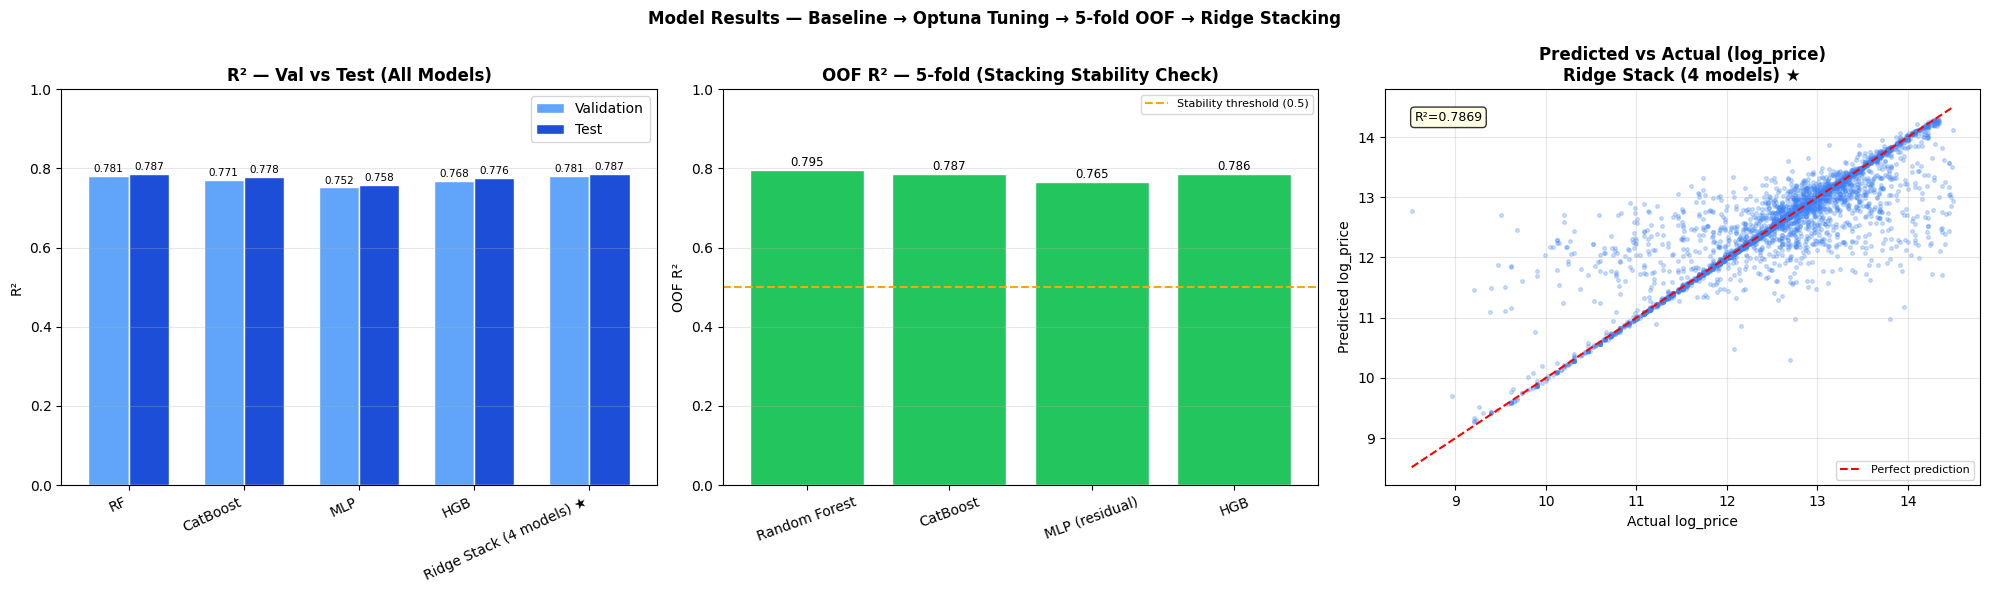

Saved → /content/drive/MyDrive/RealEstate_TXNY/model_results_summary.png

MODELLING PIPELINE COMPLETE
  Best model   : Ridge Stack (4 models) ★
  Best test R² : 0.7869
  Real-$ MAE   : $62,473


In [7]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 28 — RESULTS VISUALIZATION                                 ║
# ╚══════════════════════════════════════════════════════════════════╝

"""
3-panel visualisation:
  Panel 1: R² comparison — all 5 models + stack (val vs test)
  Panel 2: OOF R² per model — shows which models are the most reliable
  Panel 3: Predicted vs Actual (log price) for best model — test set
"""

print("=" * 65)
print("CELL 28 — RESULTS VISUALISATION")
print("=" * 65)

fig_res, axes_r = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: Val R² vs Test R² for all 5 + stack
ax_r = axes_r[0]
model_labels = [r["model"].replace(" (tuned)","").replace(" (residual,tuned)","")
                for r in final_results]
val_r2_vals  = [r["R2"] for r in results_tuned] + [
    r2_score(y_reg_val, ridge_meta.predict(
        np.column_stack([rf_tuned.predict(Xva_rf),
                         cb_tuned.predict(Xva_rf),
                         *([denorm_y(mlp_tuned.predict(Xva_sc,verbose=0).flatten())] if INCLUDE_MLP_IN_STACK else []),
                         hgb_tuned.predict(Xva_raw)])))]
test_r2_vals = [r["R2"] for r in final_results]
x_pos_r      = np.arange(len(model_labels))
width_r      = 0.35
ax_r.bar(x_pos_r - width_r/2, val_r2_vals[:len(model_labels)],
          width_r, label="Validation", color="#60A5FA", edgecolor="white")
ax_r.bar(x_pos_r + width_r/2, test_r2_vals,
          width_r, label="Test", color="#1D4ED8", edgecolor="white")
ax_r.set_xticks(x_pos_r); ax_r.set_xticklabels(model_labels, rotation=25, ha="right")
ax_r.set_ylabel("R²"); ax_r.set_ylim(0, 1)
ax_r.set_title("R² — Val vs Test (All Models)", fontweight="bold")
ax_r.legend(); ax_r.grid(axis="y", alpha=0.3)
for i, (v, t) in enumerate(zip(val_r2_vals[:len(model_labels)], test_r2_vals)):
    ax_r.text(i - width_r/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=7.5)
    ax_r.text(i + width_r/2, t + 0.01, f"{t:.3f}", ha="center", fontsize=7.5)

# Panel 2: OOF R² per model
ax_oof = axes_r[1]
oof_names_plot = [r["Model"] for r in oof_results]
oof_r2_vals    = [r["OOF R²"] for r in oof_results]
colors_oof = ["#22C55E" if v >= MLP_THRESHOLD else "#EF4444" for v in oof_r2_vals]
bars_oof = ax_oof.bar(oof_names_plot, oof_r2_vals, color=colors_oof, edgecolor="white")
ax_oof.axhline(MLP_THRESHOLD, color="orange", linestyle="--", lw=1.5,
                label=f"Stability threshold ({MLP_THRESHOLD})")
ax_oof.set_title("OOF R² — 5-fold (Stacking Stability Check)", fontweight="bold")
ax_oof.set_ylabel("OOF R²"); ax_oof.set_ylim(0, 1)
ax_oof.legend(fontsize=8); ax_oof.grid(axis="y", alpha=0.3)
ax_oof.tick_params(axis="x", rotation=20)
for bar, v in zip(bars_oof, oof_r2_vals):
    ax_oof.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f"{v:.3f}", ha="center", fontsize=8.5)

# Panel 3: Predicted vs Actual for best model
ax_pa = axes_r[2]
best_idx  = final_df["R2"].idxmax()
best_preds = final_results[best_idx]
best_name  = best_preds["model"]
# Get the actual test predictions
preds_lookup = dict(zip(
    ["RF (tuned)","CatBoost (tuned)","MLP (residual,tuned)",
     "HGB (tuned)",
     f"Ridge Stack ({len(oof_names)} models) ★"],
    [p_rf_test, p_cat_test, p_mlp_test, p_hgb_test, p_stk_test]
))
best_p = preds_lookup.get(best_name, p_stk_test)
sample_idx = np.random.choice(len(y_reg_test), min(5000, len(y_reg_test)), replace=False)
y_actual  = y_reg_test.values[sample_idx]
y_pred_p  = best_p[sample_idx]
ax_pa.scatter(y_actual, y_pred_p, alpha=0.25, s=7, color="#3B82F6")
lim = [min(y_actual.min(), y_pred_p.min()), max(y_actual.max(), y_pred_p.max())]
ax_pa.plot(lim, lim, "r--", lw=1.5, label="Perfect prediction")
ax_pa.set_title(f"Predicted vs Actual (log_price)\n{best_name}", fontweight="bold")
ax_pa.set_xlabel("Actual log_price")
ax_pa.set_ylabel("Predicted log_price")
ax_pa.legend(fontsize=8); ax_pa.grid(alpha=0.3)
ax_pa.text(0.05, 0.92, f"R²={best_preds['R2']:.4f}",
            transform=ax_pa.transAxes, fontsize=9,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.suptitle("Model Results — Baseline → Optuna Tuning → 5-fold OOF → Ridge Stacking",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/model_results_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {SAVE_DIR}/model_results_summary.png")

print(f"\n{'='*65}")
print("MODELLING PIPELINE COMPLETE")
print("="*65)
print(f"  Best model   : {best_model['model']}")
print(f"  Best test R² : {best_model['R2']:.4f}")
print(f"  Real-$ MAE   : ${best_model['Real_MAE_USD']:,.0f}")



# Cell 29 - Regression: Baseline vs Fine-Tuned (Test Set)

*Does optuna tuning and stacking actually helping?* by training a fresh baseline i.e, untuned, default-hyperparameter. Versions of every model and compare each against the tuned counterpart on the test set.

Metrics computed for every model (baseline **and** tuned): R², RMSE, MAE,
MAPE, and back-transformed real-dollar MAE.

Producing three plots:
1. Grouped bar chart — baseline vs fine-tuned R² per model, with the Ridge
   Stack R² drawn as a reference line.
2. KDE of residuals (actual - predicted log price) for all tuned models.
3. Predicted-vs-actual scatter for the Ridge Stack, annotated with R² and
   real-dollar MAE.

Saves the combined figure to `cell29_regression_test.png`.


CELL 29 — REGRESSION: BASELINE vs FINE-TUNED (TEST SET)

REGRESSION TEST SET RESULTS — BASELINE vs TUNED:
                 Model     R²   RMSE    MAE   MAPE%  Real_MAE_$
Random Forest Baseline 0.7726 0.4325 0.1652 32.6898  58454.5190
   Random Forest Tuned 0.7867 0.4189 0.1711 34.7374  62236.9018
     CatBoost Baseline 0.7602 0.4441 0.2044 38.7967  74853.7646
        CatBoost Tuned 0.7779 0.4274 0.1868 37.6174  67420.3300
          MLP Baseline 0.7415 0.4611 0.2437 42.4645  93785.6986
             MLP Tuned 0.7580 0.4461 0.1982 39.1874  71728.0122
          HGB Baseline 0.7670 0.4378 0.2005 38.8579  73457.5774
             HGB Tuned 0.7755 0.4297 0.1980 38.8950  71388.5511
         Ridge Stack ★ 0.7869 0.4187 0.1729 35.0714  62473.3719


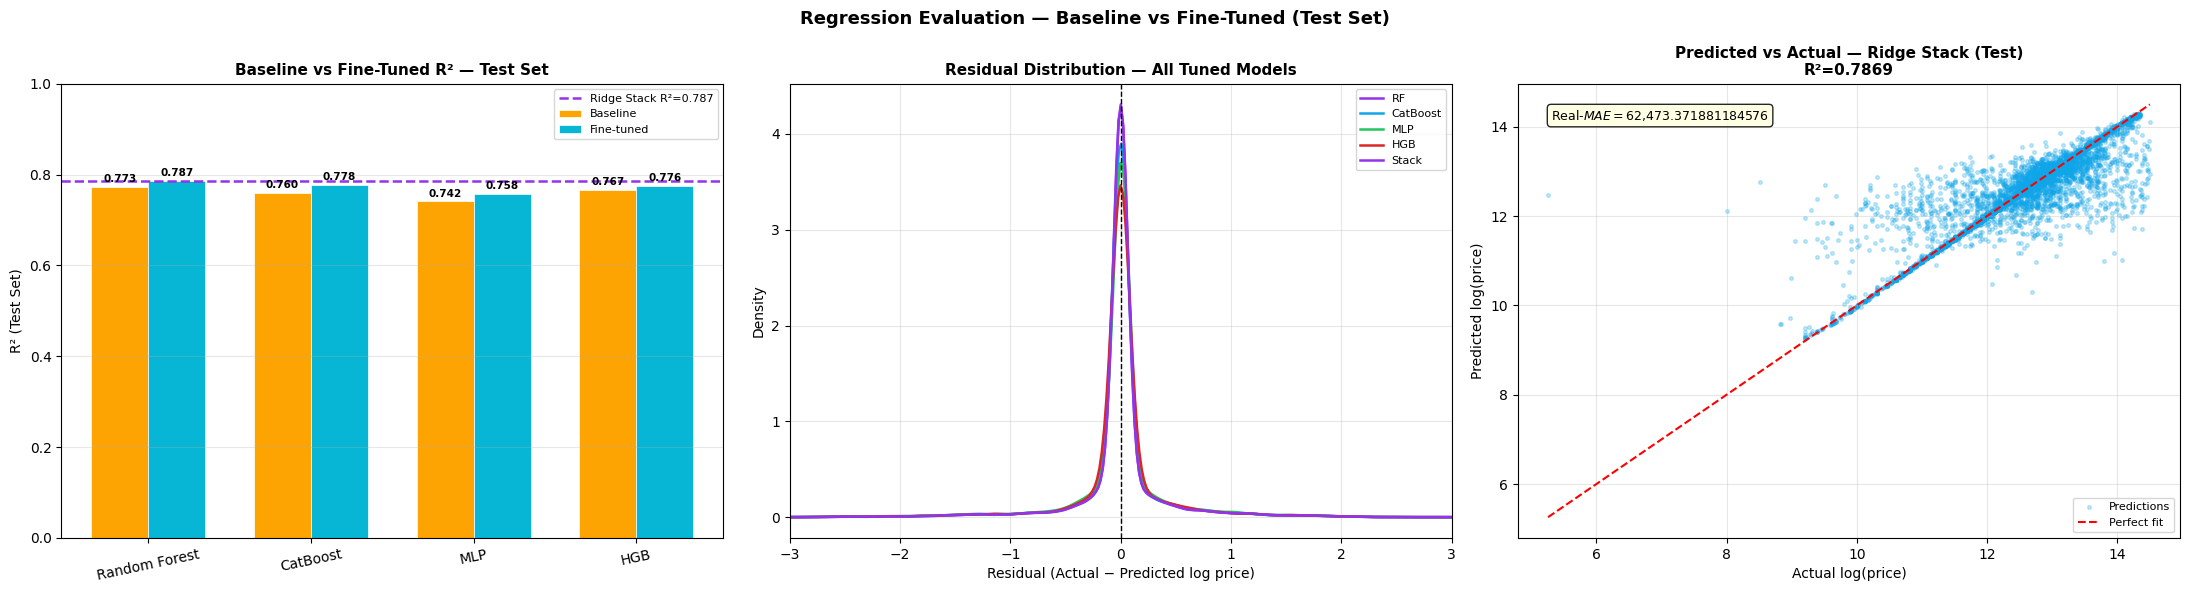


Saved → /content/drive/MyDrive/RealEstate_TXNY/cell29_regression_test.png


In [9]:
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 70)
print("CELL 29 — REGRESSION: BASELINE vs FINE-TUNED (TEST SET)")
print("=" * 70)

# Define PAL for consistent colors across plots
PAL = {
    "Baseline": "#FDA403",
    "Tuned":    "#06B6D4",
    "Stack":    "#9333EA",
    "RF":         "#9333EA", # for consistent colors across plots
    "CatBoost":   "#0EA5E9",
    "MLP":        "#22C55E",
    "HGB":        "#DC2626",
    "TX":         "#2563EB",
    "NY":         "#DC2626",
}

# ── Baseline test predictions ─────────────────────────────────────────────────
from sklearn.impute import SimpleImputer
imp_bl = SimpleImputer(strategy="median")
Xtr_bl = imp_bl.fit_transform(X_train[final_features].values)
Xts_bl = imp_bl.transform(X_test[final_features].values)

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import ElasticNet
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_percentage_error # Import this function

rf_bl_m   = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=SEED)
rf_bl_m.fit(Xtr_bl, y_reg_train)

cb_bl_m   = CatBoostRegressor(iterations=500, learning_rate=0.03,
                               depth=6, random_seed=SEED, verbose=0)
cb_bl_m.fit(Xtr_bl, y_reg_train)

hgb_bl_m  = HistGradientBoostingRegressor(random_state=SEED)
hgb_bl_m.fit(X_train[final_features].values, y_reg_train)

en_bl_m   = ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=1000, random_state=SEED)
en_bl_m.fit(Xtr_sc, y_reg_train)

from tensorflow.keras import Input as KInput, Model as KModel
from tensorflow.keras import layers as KL
mlp_bl_m_obj = keras.Sequential([
    KL.Input(shape=(n_feat,)),
    KL.Dense(128, activation="relu"),
    KL.BatchNormalization(),
    KL.Dropout(0.3),
    KL.Dense(64, activation="relu"),
    KL.Dense(1),
])
mlp_bl_m_obj.compile(optimizer=keras.optimizers.Adam(0.001), loss="mse")
mlp_bl_m_obj.fit(Xtr_sc, norm_y(y_reg_train.values),
                  validation_split=0.1, epochs=30, batch_size=256, verbose=0,
                  callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)])

p_rf_bl_ts   = rf_bl_m.predict(Xts_bl)
p_cb_bl_ts   = cb_bl_m.predict(Xts_bl)
p_hgb_bl_ts  = hgb_bl_m.predict(X_test[final_features].values)
p_en_bl_ts   = en_bl_m.predict(Xts_sc)
p_mlp_bl_ts  = denorm_y(mlp_bl_m_obj.predict(Xts_sc, verbose=0).flatten())

def full_metrics(y_true, y_pred, label):
    """Return full metrics dict with real-dollar quantities."""
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    rmse     = np.sqrt(mean_squared_error(y_true_arr, y_pred_arr))
    mae      = mean_absolute_error(y_true_arr, y_pred_arr)
    r2       = r2_score(y_true_arr, y_pred_arr)
    real_t   = np.expm1(y_true_arr)
    real_p   = np.expm1(y_pred_arr)
    real_mae = mean_absolute_error(real_t, real_p)
    mape = np.mean(np.abs((real_t - real_p) / np.clip(real_t, 1, None))) * 100
    return {"Model": label, "R²": r2, "RMSE": rmse,
            "MAE": mae, "MAPE%": mape, "Real_MAE_$": real_mae}

y_ts = y_reg_test.values

# Build full table
rows_reg = []
for label, bl_p, tu_p in [
    ("Random Forest",  p_rf_bl_ts,  p_rf_test),
    ("CatBoost",       p_cb_bl_ts,  p_cat_test),
    ("MLP",            p_mlp_bl_ts, p_mlp_test),
    ("HGB",            p_hgb_bl_ts, p_hgb_test),
    ("Ridge Stack",    None,        p_stk_test),
]:
    if bl_p is not None:
        m_bl = full_metrics(y_ts, bl_p,  f"{label} Baseline")
        m_tu = full_metrics(y_ts, tu_p,  f"{label} Tuned")
        rows_reg.extend([m_bl, m_tu])
    else:
        rows_reg.append(full_metrics(y_ts, tu_p, f"{label} ★"))

reg_df = pd.DataFrame(rows_reg)
print("\nREGRESSION TEST SET RESULTS — BASELINE vs TUNED:")
print(reg_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ── Plot 1: Baseline vs Tuned R² bar chart ────────────────────────────────────
model_names_5 = ["Random Forest","CatBoost","MLP","HGB"]
bl_r2_ts = [full_metrics(y_ts, p, "R²")["R²"]
             for p in [p_rf_bl_ts, p_cb_bl_ts, p_mlp_bl_ts, p_hgb_bl_ts]]
tu_r2_ts = [full_metrics(y_ts, p, "R²")["R²"]
             for p in [p_rf_test, p_cat_test, p_mlp_test, p_hgb_test]]
stk_r2   = full_metrics(y_ts, p_stk_test, "R²")["R²"]

fig29, axes29 = plt.subplots(1, 3, figsize=(22, 6))

ax = axes29[0]
x_p = np.arange(len(model_names_5))
w   = 0.35
bars_bl = ax.bar(x_p - w/2, bl_r2_ts, w,
                  label="Baseline", color=PAL["Baseline"], edgecolor="white", linewidth=0.5)
bars_tu = ax.bar(x_p + w/2, tu_r2_ts, w,
                  label="Fine-tuned", color=PAL["Tuned"], edgecolor="white", linewidth=0.5)
ax.axhline(stk_r2, color=PAL["Stack"], linestyle="--", linewidth=1.8,
            label=f"Ridge Stack R²={stk_r2:.3f}")
ax.set_xticks(x_p); ax.set_xticklabels(model_names_5, rotation=12)
ax.set_ylim(0, 1); ax.set_ylabel("R² (Test Set)")
ax.set_title("Baseline vs Fine-Tuned R² — Test Set", fontweight="bold", fontsize=11)
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
for bar, v in list(zip(bars_bl, bl_r2_ts)) + list(zip(bars_tu, tu_r2_ts)):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
             f"{v:.3f}", ha="center", fontsize=7.5, fontweight="bold")

# ── Plot 2: Residual distributions ───────────────────────────────────────────
ax2 = axes29[1]
model_preds_named = {
    "RF":         p_rf_test,
    "CatBoost":   p_cat_test,
    "MLP":        p_mlp_test,
    "HGB":        p_hgb_test,
    "Stack":      p_stk_test,
}
for mname, pred in model_preds_named.items():
    residuals = y_ts - pred
    pd.Series(residuals).plot.kde(ax=ax2, label=mname,
                                   color=PAL.get(mname, "gray"), linewidth=1.8)
ax2.axvline(0, color="black", linestyle="--", linewidth=1)
ax2.set_xlabel("Residual (Actual − Predicted log price)")
ax2.set_ylabel("Density")
ax2.set_title("Residual Distribution — All Tuned Models", fontweight="bold", fontsize=11)
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
ax2.set_xlim(-3, 3)

# ── Plot 3: Predicted vs Actual — best model ──────────────────────────────────
ax3 = axes29[2]
best_name_reg = reg_df.loc[reg_df["R²"].idxmax(), "Model"]
best_pred_reg = {
    "Ridge Stack ★": p_stk_test,
    "CatBoost Tuned": p_cat_test,
    "HGB Tuned": p_hgb_test,
    "Random Forest Tuned": p_rf_test,
}.get(best_name_reg, p_stk_test)
# fallback to stack
best_pred_reg = p_stk_test
sidx = np.random.choice(len(y_ts), min(8000, len(y_ts)), replace=False)
y_actual  = y_reg_test.values[sidx]
y_pred_p  = best_pred_reg[sidx]
sc = ax3.scatter(y_actual, y_pred_p,
                  alpha=0.25, s=7, c=PAL["CatBoost"], label="Predictions")
lims = [min(y_ts.min(), best_pred_reg.min()), max(y_ts.max(), best_pred_reg.max())]
ax3.plot(lims, lims, "r--", linewidth=1.5, label="Perfect fit")
ax3.set_xlabel("Actual log(price)"); ax3.set_ylabel("Predicted log(price)")
ax3.set_title(f"Predicted vs Actual — Ridge Stack (Test)\nR²={stk_r2:.4f}",
               fontweight="bold", fontsize=11)
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)
ax3.text(0.05, 0.92, f"Real-$ MAE = ${full_metrics(y_ts,p_stk_test,'')["Real_MAE_$"]:,}",
          transform=ax3.transAxes, fontsize=9,
          bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.85))

plt.suptitle("Regression Evaluation — Baseline vs Fine-Tuned (Test Set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/cell29_regression_test.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved → {SAVE_DIR}/cell29_regression_test.png")

# Checkpoint - Save State for Notebook 6
Serialises each notebook-level variable (excluding modules, matplotlib
objects, and underscore-prefixed temporaries) to `checkpoint_5_to_6.pkl`
via `dill`, saving Keras models separately as `.keras` files referenced by
a companion JSON. Anything which fails to pickle is recorded in `_skipped`
rather than dropping it completely, so Notebook 6 can restore this exact state
and continue straight into classification / SHAP interpretability.


In [10]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CHECKPOINT — SAVE STATE FOR Notebook 6                          ║
# ╚══════════════════════════════════════════════════════════════════╝

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "dill", "-q"])
import dill, types, json, os

CKPT_DIR  = f"{SAVE_DIR}/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_NAME = "checkpoint_5_to_6"

_keras_models = {}
_state        = {}
_skipped      = []
_reserved     = {"_keras_models", "_state", "_skipped", "_reserved",
                  "_name", "_val", "_path", "CKPT_DIR", "CKPT_NAME"}

for _name, _val in list(globals().items()):
    if _name.startswith("_") or _name in _reserved:
        continue
    try:
        if isinstance(_val, types.ModuleType):
            continue
        if type(_val).__module__.startswith("matplotlib"):
            continue
        if isinstance(_val, tf.keras.Model):
            _path = f"{CKPT_DIR}/{CKPT_NAME}__{_name}.keras"
            _val.save(_path)
            _keras_models[_name] = _path
            continue
        dill.dumps(_val)
        _state[_name] = _val
    except Exception:
        _skipped.append(_name)

with open(f"{CKPT_DIR}/{CKPT_NAME}.pkl", "wb") as f:
    dill.dump(_state, f)
with open(f"{CKPT_DIR}/{CKPT_NAME}_keras.json", "w") as f:
    json.dump(_keras_models, f)

print("=" * 65)
print(f"CHECKPOINT SAVED -> {CKPT_DIR}/{CKPT_NAME}.pkl")
print("=" * 65)
print(f"  Variables saved    : {len(_state)}")
print(f"  Keras models saved : {list(_keras_models.keys()) or 'none'}")
if _skipped:
    print(f"  Skipped (not needed downstream / not picklable): {_skipped}")
print("from its first cell — it will restore this state automatically.")

CHECKPOINT SAVED -> /content/drive/MyDrive/RealEstate_TXNY/checkpoints/checkpoint_5_to_6.pkl
  Variables saved    : 493
  Keras models saved : ['mlp_base_model', 'mlp_tuned', 'mlp_f', 'mlp_bl_m_obj']
  Skipped (not needed downstream / not picklable): ['get_ipython', 'exit', 'quit']
from its first cell — it will restore this state automatically.
